# FastJet contrib demo via hepyy

Demonstrates **SoftDrop grooming**, **Nsubjettiness** (τ₂₁), and **EnergyCorrelator** (C₂)  
on Pythia8 QCD dijet events at 13 TeV with large-R anti-kₜ jets.

Run `hepyy init` and `hepyy install fastjet pythia8 fjcontrib` once before starting the kernel.

In [7]:
# hepyy.load() is a no-op if packages were already loaded via
# `module load` or the hepyy Jupyter kernel. Safe to leave in place.
import hepyy
hepyy.load('fastjet')
hepyy.load('fjcontrib')
hepyy.load('pythia8')

In [ ]:
import cppyy
import pythia8
import fastjet
import fjcontrib

# Sanity check: cppyy location
print(f"cppyy from: {cppyy.__file__}")

PseudoJetVec = cppyy.gbl.std.vector[fastjet.PseudoJet]

## Configure Pythia8 and analysis objects

In [ ]:
# Jet parameters
R      = 0.8
pt_min = 200.0  # GeV

jet_def = fastjet.JetDefinition(fastjet.antikt_algorithm, R)

# SoftDrop: β=0, z_cut=0.1  (mMDT-like)
sd = fjcontrib.SoftDrop(0.0, 0.1, R)

# Nsubjettiness — axes/measure objects must outlive the calculator instances
_axes   = fjcontrib.KT_Axes()
_meas   = fjcontrib.UnnormalizedMeasure(1.0)
tau1_fn = fjcontrib.Nsubjettiness(1, _axes, _meas)
tau2_fn = fjcontrib.Nsubjettiness(2, _axes, _meas)
tau3_fn = fjcontrib.Nsubjettiness(3, _axes, _meas)

# EnergyCorrelator: C2 = e3 / e2²
ec2_fn = fjcontrib.EnergyCorrelator(2, 1.0)
ec3_fn = fjcontrib.EnergyCorrelator(3, 1.0)

# Pythia8
pythia = pythia8.Pythia()
pythia.readString('Beams:eCM = 13000.')
pythia.readString('HardQCD:all = on')
pythia.readString('PhaseSpace:pTHatMin = 200.')
pythia.readString('Next:numberShowEvent = 0')
pythia.readString('Print:quiet = on')
pythia.init()

## Event loop

In [ ]:
n_events = 500

jet_mass     = []
groomed_mass = []
tau21_vals   = []
tau32_vals   = []
c2_vals      = []

for _ in range(n_events):
    if not pythia.next():
        continue

    particles = PseudoJetVec()
    for i in range(pythia.event.size()):
        p = pythia.event[i]
        if p.isFinal() and p.isVisible():
            particles.push_back(fastjet.PseudoJet(p.px(), p.py(), p.pz(), p.e()))

    cs   = fastjet.ClusterSequence(particles, jet_def)
    jets = fastjet.sorted_by_pt(cs.inclusive_jets(pt_min))

    for jet in jets:
        groomed = sd.result(jet)
        t1 = tau1_fn(jet)
        t2 = tau2_fn(jet)
        t3 = tau3_fn(jet)
        e2 = ec2_fn(jet)
        e3 = ec3_fn(jet)

        jet_mass.append(jet.m())
        groomed_mass.append(groomed.m())
        if t1 > 0: tau21_vals.append(t2 / t1)
        if t2 > 0: tau32_vals.append(t3 / t2)
        if e2 > 0: c2_vals.append(e3 / e2**2)

print(f'Processed {n_events} events')
print(f'Total jets (pT > {pt_min} GeV): {len(jet_mass)}')
print(f'Mean tau21: {sum(tau21_vals)/len(tau21_vals):.3f}')
print(f'Mean C2:    {sum(c2_vals)/len(c2_vals):.3f}')

## Plots

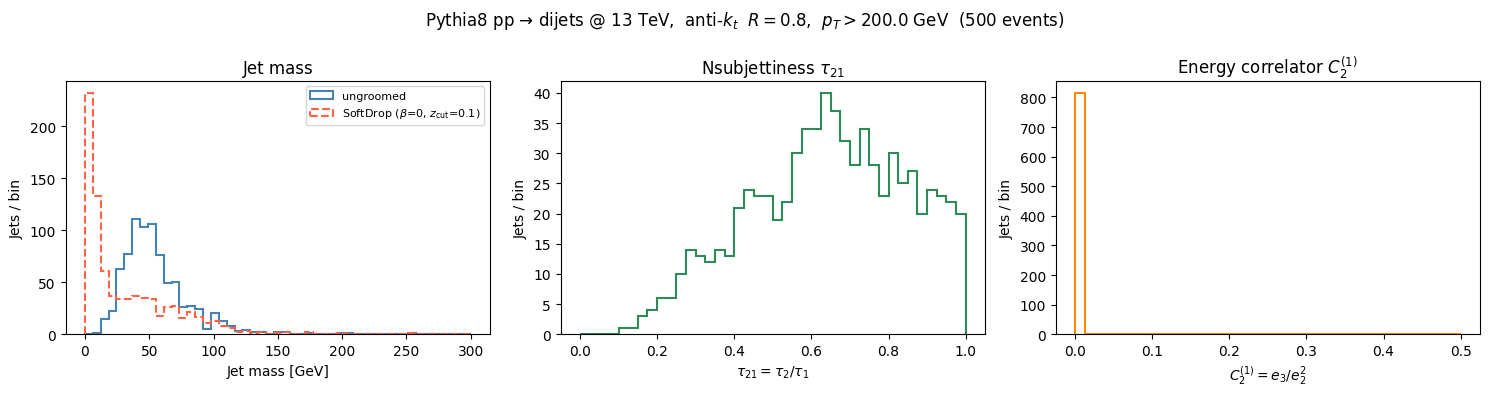

Saved demo_fjcontrib.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f'Pythia8 pp → dijets @ 13 TeV,  anti-$k_t$  $R={R}$,  '
    f'$p_T > {pt_min}$ GeV  ({n_events} events)'
)

# Jet mass: ungroomed vs SoftDrop
ax = axs[0]
bins = np.linspace(0, 300, 50)
ax.hist(jet_mass,     bins=bins, histtype='step', lw=1.5, color='steelblue', label='ungroomed')
ax.hist(groomed_mass, bins=bins, histtype='step', lw=1.5, color='tomato',    ls='--',
        label=r'SoftDrop ($\beta$=0, $z_{\rm cut}$=0.1)')
ax.set_xlabel('Jet mass [GeV]')
ax.set_ylabel('Jets / bin')
ax.set_title('Jet mass')
ax.legend(fontsize=8)

# Nsubjettiness τ21
ax = axs[1]
ax.hist(tau21_vals, bins=40, range=(0, 1), histtype='step', lw=1.5, color='seagreen')
ax.set_xlabel(r'$\tau_{21} = \tau_2/\tau_1$')
ax.set_ylabel('Jets / bin')
ax.set_title(r'Nsubjettiness $\tau_{21}$')

# EnergyCorrelator C2
ax = axs[2]
ax.hist(c2_vals, bins=40, range=(0, 0.5), histtype='step', lw=1.5, color='darkorange')
ax.set_xlabel(r'$C_2^{(1)} = e_3 / e_2^2$')
ax.set_ylabel('Jets / bin')
ax.set_title(r'Energy correlator $C_2^{(1)}$')

plt.tight_layout()
plt.savefig('demo_fjcontrib.png', dpi=150)
plt.show()
print('Saved demo_fjcontrib.png')

## Inspect a single jet

In [ ]:
# Generate one fresh event and show detailed substructure
while not pythia.next():
    pass

particles = PseudoJetVec()
for i in range(pythia.event.size()):
    p = pythia.event[i]
    if p.isFinal() and p.isVisible():
        particles.push_back(fastjet.PseudoJet(p.px(), p.py(), p.pz(), p.e()))

cs   = fastjet.ClusterSequence(particles, jet_def)
jets = fastjet.sorted_by_pt(cs.inclusive_jets(pt_min))

print(f'{len(particles)} particles → {len(jets)} jets (pT > {pt_min} GeV)\n')
print(f"  {'#':<3} {'pT':>8} {'eta':>7} {'m':>8} {'m_SD':>8} {'tau1':>7} {'tau2':>7} {'tau21':>7} {'C2':>7}")
print('  ' + '-'*68)
for j, jet in enumerate(jets):
    groomed = sd.result(jet)
    t1 = tau1_fn(jet); t2 = tau2_fn(jet)
    e2 = ec2_fn(jet);  e3 = ec3_fn(jet)
    tau21 = t2/t1 if t1 > 0 else float('nan')
    c2    = e3/e2**2 if e2 > 0 else float('nan')
    print(f'  {j:<3} {jet.pt():>8.2f} {jet.eta():>7.3f} {jet.m():>8.2f} '
          f'{groomed.m():>8.2f} {t1:>7.3f} {t2:>7.3f} {tau21:>7.3f} {c2:>7.3f}')